In [1]:
import csv
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from transformers import AutoTokenizer

/home/alex/projects/tf_cuda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_ROOT = Path("/mnt/d/DataSets/Flickr30k")
IMAGES_DIR = DATASET_ROOT / "flickr30k_images"
CAPTIONS_FILE = DATASET_ROOT / "captions.txt"
NORMALIZATION_FILE_PATH = Path("flickr30k_normalization.json")
IMAGE_SIZE = 128

In [3]:
captions_by_image = {}

with CAPTIONS_FILE.open(encoding="utf-8", newline="") as file:
    reader = csv.DictReader(file)
    for row in reader:
        captions_by_image.setdefault(row["image_name"], []).append(row["comment"].strip())

image_names = sorted(captions_by_image)
SPLIT_SEED = 42

train_images, val_test_images = train_test_split(
    image_names, test_size=0.2, random_state=SPLIT_SEED, shuffle=True
)
val_images, test_images = train_test_split(
    val_test_images, test_size=0.5, random_state=SPLIT_SEED, shuffle=True
)

print(f"Train: {len(train_images)} | Val: {len(val_images)} | Test: {len(test_images)}")

Train: 25426 | Val: 3178 | Test: 3179


In [4]:
stats_transform = transforms.Compose([
    transforms.Resize(144),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
])

channel_sum = torch.zeros(3, dtype=torch.float64)
channel_squared_sum = torch.zeros(3, dtype=torch.float64)
pixel_count = 0

for image_name in tqdm(train_images, desc="Normalization"):
    with Image.open(IMAGES_DIR / image_name) as image:
        image_tensor = stats_transform(image.convert("RGB")).to(torch.float64)

    channel_sum += image_tensor.sum(dim=(1, 2))
    channel_squared_sum += image_tensor.square().sum(dim=(1, 2))
    pixel_count += image_tensor.shape[1] * image_tensor.shape[2]

train_mean = channel_sum / pixel_count
train_std = (channel_squared_sum / pixel_count - train_mean.square()).sqrt()

normalization = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
}
NORMALIZATION_FILE_PATH.write_text(json.dumps(normalization, indent=2), encoding="utf-8")

print("Mean:", train_mean.tolist())
print("Std: ", train_std.tolist())

Normalization: 100%|█████████████████████████████████████████████████████████████| 25426/25426 [02:33<00:00, 165.83it/s]

Mean: [0.4514892488928865, 0.4222841654861776, 0.3858698187801542]
Std:  [0.2713551194405635, 0.2623943174040721, 0.27047883091258135]


In [5]:
normalization = json.loads(NORMALIZATION_FILE_PATH.read_text(encoding="utf-8"))
train_mean = torch.tensor(normalization["mean"], dtype=torch.float64)
train_std = torch.tensor(normalization["std"], dtype=torch.float64)

In [6]:
train_transform = transforms.Compose([
    transforms.Resize(144),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist()),
])

eval_transform = transforms.Compose([
    transforms.Resize(144),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist()),
])

In [7]:
class Flickr30kDataset(Dataset):
    def __init__(self, image_names, images_dir, captions, transform, random_caption=False):
        self.image_names = image_names
        self.images_dir = images_dir
        self.captions = captions
        self.transform = transform
        self.random_caption = random_caption

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, index):
        image_name = self.image_names[index]

        with Image.open(self.images_dir / image_name) as image:
            image = self.transform(image.convert("RGB"))

        image_captions = self.captions[image_name]
        caption = random.choice(image_captions) if self.random_caption else image_captions[0]

        return {
            "image": image,
            "caption": caption,
            "filename": image_name,
        }

In [8]:
train_dataset = Flickr30kDataset(
    train_images, IMAGES_DIR, captions_by_image, train_transform, random_caption=True
)
val_dataset = Flickr30kDataset(
    val_images, IMAGES_DIR, captions_by_image, eval_transform
)
test_dataset = Flickr30kDataset(
    test_images, IMAGES_DIR, captions_by_image, eval_transform
)

In [9]:
device = torch.device("cuda")

BATCH_SIZE = 64
NUM_WORKERS = 6

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

In [10]:
TOKENIZER_NAME = "bert-base-uncased"
MAX_TEXT_LENGTH = 32

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
tokenizer.save_pretrained("../models/tokenizer")

('../models/tokenizer/tokenizer_config.json',
 '../models/tokenizer/tokenizer.json')

In [11]:
class ImageEncoder(nn.Module):
    def __init__(
        self,
        image_size=128,
        patch_size=16,
        d_model=128,
        num_heads=4,
        num_layers=2,
        embedding_dim=128,
        dropout=0.1,
    ):
        super().__init__()

        num_patches = (image_size // patch_size) ** 2

        self.patch_embedding = nn.Conv2d(
            in_channels=3,
            out_channels=d_model,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.position_embedding = nn.Parameter(
            torch.randn(1, num_patches, d_model) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.projection = nn.Linear(d_model, embedding_dim)

    def forward(self, images):
        tokens = self.patch_embedding(images)
        tokens = tokens.flatten(2).transpose(1, 2)
        tokens = tokens + self.position_embedding

        tokens = self.transformer(tokens)
        embedding = tokens.mean(dim=1)
        embedding = self.projection(embedding)

        return F.normalize(embedding, dim=-1)

In [12]:
class TextEncoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_length=32,
        pad_token_id=0,
        d_model=128,
        num_heads=4,
        num_layers=2,
        embedding_dim=128,
        dropout=0.1,
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model,
            padding_idx=pad_token_id,
        )
        self.position_embedding = nn.Parameter(
            torch.randn(1, max_length, d_model) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.projection = nn.Linear(d_model, embedding_dim)

    def forward(self, input_ids, attention_mask):
        sequence_length = input_ids.shape[1]

        tokens = self.token_embedding(input_ids)
        tokens = tokens + self.position_embedding[:, :sequence_length]

        tokens = self.transformer(
            tokens,
            src_key_padding_mask=attention_mask == 0,
        )

        mask = attention_mask.unsqueeze(-1).float()
        embedding = (tokens * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1)
        embedding = self.projection(embedding)

        return F.normalize(embedding, dim=-1)

In [13]:
def contrastive_loss(image_embeddings, text_embeddings, temperature=0.07):
    logits = image_embeddings @ text_embeddings.T
    logits = logits / temperature

    labels = torch.arange(
        image_embeddings.shape[0],
        device=image_embeddings.device,
    )

    image_to_text_loss = F.cross_entropy(logits, labels)
    text_to_image_loss = F.cross_entropy(logits.T, labels)

    loss = (image_to_text_loss + text_to_image_loss) / 2

    return loss

In [14]:
def train_model(
    image_encoder,
    text_encoder,
    tokenizer,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    device,
    max_text_length=32,
    epochs=20,
    grad_clip=1.0,
    amp=True,
    early_stopping_patience=5,
    early_stopping_min_delta=0.001,
    save_path=None,
    save_freq=1,
):
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    image_encoder.to(device)
    text_encoder.to(device)

    scaler = torch.cuda.amp.GradScaler(enabled=amp)

    for epoch in range(epochs):
        image_encoder.train()
        text_encoder.train()

        epoch_train_loss = 0.0
        train_tqdm = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [train]")

        for batch in train_tqdm:
            images = batch["image"].to(device, non_blocking=True)

            text_batch = tokenizer(
                list(batch["caption"]),
                padding="max_length",
                truncation=True,
                max_length=max_text_length,
                return_tensors="pt",
            )
            input_ids = text_batch["input_ids"].to(device, non_blocking=True)
            attention_mask = text_batch["attention_mask"].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=amp):
                image_embeddings = image_encoder(images)
                text_embeddings = text_encoder(input_ids, attention_mask)
                loss = loss_function(image_embeddings, text_embeddings)

            scaler.scale(loss).backward()

            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    list(image_encoder.parameters()) + list(text_encoder.parameters()),
                    grad_clip,
                )

            scaler.step(optimizer)
            scaler.update()

            epoch_train_loss += loss.item()
            train_tqdm.set_postfix(loss=f"{loss.item():.4f}")

        epoch_train_loss /= max(1, len(train_loader))
        train_losses.append(epoch_train_loss)

        image_encoder.eval()
        text_encoder.eval()

        epoch_val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device, non_blocking=True)

                text_batch = tokenizer(
                    list(batch["caption"]),
                    padding="max_length",
                    truncation=True,
                    max_length=max_text_length,
                    return_tensors="pt",
                )
                input_ids = text_batch["input_ids"].to(device, non_blocking=True)
                attention_mask = text_batch["attention_mask"].to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=amp):
                    image_embeddings = image_encoder(images)
                    text_embeddings = text_encoder(input_ids, attention_mask)
                    loss = loss_function(image_embeddings, text_embeddings)

                epoch_val_loss += loss.item()

        epoch_val_loss /= max(1, len(val_loader))
        val_losses.append(epoch_val_loss)

        improved = epoch_val_loss < best_val_loss - early_stopping_min_delta
        if improved:
            best_val_loss = epoch_val_loss
            epochs_without_improvement = 0

            if save_path and ((epoch + 1) % save_freq == 0):
                checkpoint = {
                    "epoch": epoch + 1,
                    "image_encoder_state_dict": image_encoder.state_dict(),
                    "text_encoder_state_dict": text_encoder.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict()
                }
                torch.save(checkpoint, f"{save_path}/Epoch[{epoch + 1}].tar")
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.6f} | "
            f"Val Loss: {epoch_val_loss:.6f}"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break
    return train_losses, val_losses

In [15]:
def draw_train_val_loss(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Val Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Val Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [16]:
def compute_metrics(similarity_matrix, positive_mask, k_values=(1, 5, 10)):
    ranked_indices = similarity_matrix.argsort(dim=1, descending=True)
    ranked_positives = positive_mask.gather(dim=1, index=ranked_indices)

    ranks = ranked_positives.float().argmax(dim=1) + 1

    metrics = {
        "mean_rank": ranks.float().mean().item(),
        "median_rank": ranks.float().median().item(),
    }

    for k in k_values:
        metrics[f"recall@{k}"] = (ranks <= k).float().mean().item()

    return metrics

In [17]:
def test_model(
    image_encoder,
    text_encoder,
    test_loader,
    tokenizer,
    device,
    loss_function=None,
    max_text_length=32,
    text_batch_size=256,
    k_values=(1, 5, 10),
    amp=True,
):
    image_encoder.eval()
    text_encoder.eval()

    image_embeddings_list = []
    filenames = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing [images]"):
            images = batch["image"].to(device, non_blocking=True)

            if loss_function is not None:
                text_batch = tokenizer(
                    list(batch["caption"]),
                    padding="max_length",
                    truncation=True,
                    max_length=max_text_length,
                    return_tensors="pt",
                )
                input_ids = text_batch["input_ids"].to(device, non_blocking=True)
                attention_mask = text_batch["attention_mask"].to(
                    device, non_blocking=True
                )

            with torch.cuda.amp.autocast(enabled=amp):
                image_embeddings = image_encoder(images)
                if loss_function is not None:
                    text_embeddings = text_encoder(input_ids, attention_mask)
                    loss = loss_function(image_embeddings, text_embeddings)
                    total_loss += loss.item()

            image_embeddings_list.append(image_embeddings.cpu())
            filenames.extend(batch["filename"])

    image_embeddings = torch.cat(image_embeddings_list, dim=0)

    captions = []
    caption_image_indices = []
    captions_by_image = test_loader.dataset.captions

    for image_index, filename in enumerate(filenames):
        for caption in captions_by_image[filename]:
            captions.append(caption)
            caption_image_indices.append(image_index)

    text_embeddings_list = []

    with torch.no_grad():
        for start in tqdm(range(0, len(captions), text_batch_size), desc="Testing [texts]"):
            caption_batch = captions[start : start + text_batch_size]
            text_batch = tokenizer(
                caption_batch,
                padding="max_length",
                truncation=True,
                max_length=max_text_length,
                return_tensors="pt",
            )
            input_ids = text_batch["input_ids"].to(device, non_blocking=True)
            attention_mask = text_batch["attention_mask"].to(
                device, non_blocking=True
            )

            with torch.cuda.amp.autocast(enabled=amp):
                text_embeddings = text_encoder(input_ids, attention_mask)

            text_embeddings_list.append(text_embeddings.cpu())

    text_embeddings = torch.cat(text_embeddings_list, dim=0)
    caption_image_indices = torch.tensor(caption_image_indices)

    text_to_image_similarity = text_embeddings @ image_embeddings.T
    text_to_image_positive_mask = torch.zeros(
        text_to_image_similarity.shape,
        dtype=torch.bool,
    )
    text_to_image_positive_mask[
        torch.arange(len(captions)),
        caption_image_indices,
    ] = True

    text_to_image_metrics = compute_metrics(
        text_to_image_similarity,
        text_to_image_positive_mask,
        k_values=k_values,
    )

    image_to_text_metrics = compute_metrics(
        text_to_image_similarity.T,
        text_to_image_positive_mask.T,
        k_values=k_values,
    )

    print("Text -> Image")
    for name, value in text_to_image_metrics.items():
        print(f"{name}: {value:.4f}")

    print("\nImage -> Text")
    for name, value in image_to_text_metrics.items():
        print(f"{name}: {value:.4f}")

    results = {
        "text_to_image": text_to_image_metrics,
        "image_to_text": image_to_text_metrics,
    }

    if loss_function is not None:
        results["test_loss"] = total_loss / max(1, len(test_loader))
        print(f"\nTest Loss: {results['test_loss']:.6f}")

    return results

In [19]:
MODEL_CONFIG = {
    "image_size": IMAGE_SIZE,
    "patch_size": 16,
    "d_model": 128,
    "num_heads": 4,
    "num_layers": 2,
    "embedding_dim": 128,
    "dropout": 0.1,
}

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 100

image_encoder = ImageEncoder(**MODEL_CONFIG).to(device)

text_encoder = TextEncoder(
    vocab_size=tokenizer.vocab_size,
    max_length=MAX_TEXT_LENGTH,
    pad_token_id=tokenizer.pad_token_id,
    d_model=MODEL_CONFIG["d_model"],
    num_heads=MODEL_CONFIG["num_heads"],
    num_layers=MODEL_CONFIG["num_layers"],
    embedding_dim=MODEL_CONFIG["embedding_dim"],
    dropout=MODEL_CONFIG["dropout"],
).to(device)

optimizer = torch.optim.AdamW(
    list(image_encoder.parameters()) + list(text_encoder.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

In [21]:
train_losses, val_losses = train_model(
    image_encoder=image_encoder,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=contrastive_loss,
    optimizer=optimizer,
    device=device,
    max_text_length=MAX_TEXT_LENGTH,
    epochs=EPOCHS,
    grad_clip=1.0,
    amp=True,
    early_stopping_patience=5,
    early_stopping_min_delta=0.002,
    save_path="../models/runs/",
    save_freq=3
)

/tmp/ipykernel_6956/186387125.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp)
Epoch 1/100 [train]:   0%|                                                                      | 0/397 [00:00<?, ?it/s]/tmp/ipykernel_6956/186387125.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):
Epoch 1/100 [train]: 100%|███████████████████████████████████████████████| 397/397 [00:42<00:00,  9.36it/s, loss=4.0138]
/tmp/ipykernel_6956/186387125.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


Epoch [1/100] | Train Loss: 3.972011 | Val Loss: 3.893833


Epoch 2/100 [train]: 100%|███████████████████████████████████████████████| 397/397 [00:47<00:00,  8.32it/s, loss=3.7920]


Epoch [2/100] | Train Loss: 3.882434 | Val Loss: 3.792196


Epoch 3/100 [train]: 100%|███████████████████████████████████████████████| 397/397 [00:44<00:00,  8.89it/s, loss=3.8971]


...

Epoch [83/100] | Train Loss: 2.481117 | Val Loss: 2.710307


Epoch 84/100 [train]: 100%|██████████████████████████████████████████████| 397/397 [00:45<00:00,  8.71it/s, loss=2.2938]


Epoch [84/100] | Train Loss: 2.483515 | Val Loss: 2.711766


Epoch 85/100 [train]: 100%|██████████████████████████████████████████████| 397/397 [00:45<00:00,  8.65it/s, loss=2.7755]


Epoch [85/100] | Train Loss: 2.463464 | Val Loss: 2.706622
Early stopping at epoch 85


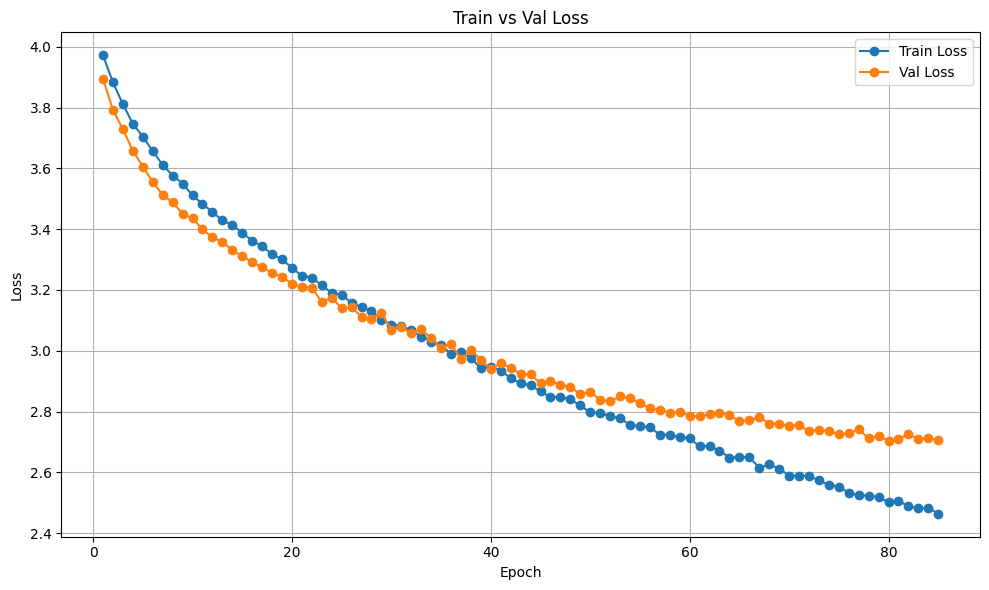

In [22]:
draw_train_val_loss(train_losses, val_losses)

In [23]:
epoch_path = Path("../models/runs/Epoch[78].tar")

checkpoint = torch.load(epoch_path)
image_encoder.load_state_dict(checkpoint["image_encoder_state_dict"])
text_encoder.load_state_dict(checkpoint["text_encoder_state_dict"])

<All keys matched successfully>

In [24]:
test_results = test_model(
    image_encoder=image_encoder,
    text_encoder=text_encoder,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=device,
    loss_function=contrastive_loss,
    max_text_length=MAX_TEXT_LENGTH,
    text_batch_size=256,
    k_values=(1, 5, 10),
    amp=True,
)

Testing [images]:   0%|                                                                          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_6956/1902696504.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):
Testing [texts]:   0%|                                                                           | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_6956/1902696504.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):
Testing [texts]: 100%|██████████████████████████████████████████████████████████████████| 63/63 [00:00<00:00, 73.34it/s]


Text -> Image
mean_rank: 409.7896
median_rank: 168.0000
recall@1: 0.0234
recall@5: 0.0796
recall@10: 0.1194

Image -> Text
mean_rank: 576.0950
median_rank: 151.0000
recall@1: 0.0299
recall@5: 0.0925
recall@10: 0.1478

Test Loss: 2.767797


In [25]:
model_save_path = Path("../models/model/model_30k.pt")

model_artifact = {
    "image_encoder_state_dict": image_encoder.state_dict(),
    "text_encoder_state_dict": text_encoder.state_dict(),
    "model_config": MODEL_CONFIG,
    "text_config": {
        "vocab_size": tokenizer.vocab_size,
        "max_length": MAX_TEXT_LENGTH,
        "pad_token_id": tokenizer.pad_token_id,
        "tokenizer_name": TOKENIZER_NAME,
    },
    "image_normalization": {
        "mean": train_mean.tolist(),
        "std": train_std.tolist(),
    },
    "epoch": checkpoint["epoch"],
}

torch.save(model_artifact, model_save_path)